# AMDNet23 Eye Disease Classification - CNN from Scratch

**Dataset:** AMDNet23 (2,000 fundus images, 4 classes: normal, diabetes, cataract, amd)

I am training the model 2 times:
- **Round 1:** no augmentation, no dropout -> this should overfit
- **Round 2:** with augmentation + dropout -> overfitting should reduce

Comparing both rounds is how I show that dropout + augmentation actually control overfitting.


## Step 1: Import libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import os

# use GPU if colab gives us one, otherwise cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

torch.manual_seed(0)
np.random.seed(0)


device: cuda


## Step 2: Upload and check the dataset

I uploaded the `AMDNet23` folder directly using the Colab file section (left sidebar -> Files -> upload folder).
So the dataset should already be sitting at `/content/AMDNet23`.

Folder structure:
```
AMDNet23/
├── train/
│   ├── normal/
│   ├── diabetes/
│   ├── cataract/
│   └── amd/
└── valid/
    ├── normal/
    ├── diabetes/
    ├── cataract/
    └── amd/
```




In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

DATA_DIR = '/content/gdrive/MyDrive/AMDNet23 Dataset'
train_dir = os.path.join(DATA_DIR, 'train')
valid_dir = os.path.join(DATA_DIR, 'valid')

print('train folder has:', os.listdir(train_dir))
print('valid folder has:', os.listdir(valid_dir))


Mounted at /content/gdrive
train folder has: ['normal', 'diabetes', 'cataract', 'amd']
valid folder has: ['normal', 'cataract', 'diabetes', 'amd']


## Step 3: Load images - Round 1 (basic transform, no augmentation)

Before an image can go into a CNN it needs to be:
- resized to the same size for every image
- turned into a tensor (numbers) instead of a normal picture file

That's it for Round 1. No flipping, no rotating - that comes later in Round 2.


In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

# just resize + convert to tensor, nothing fancy for round 1
basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ImageFolder automatically finds the class folders and labels the images
train_data = datasets.ImageFolder(train_dir, transform=basic_transform)
valid_data = datasets.ImageFolder(valid_dir, transform=basic_transform)

class_names = train_data.classes
num_classes = len(class_names)

print('classes:', class_names)
print('number of training images:', len(train_data))
print('number of validation images:', len(valid_data))

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False)


classes: ['amd', 'cataract', 'diabetes', 'normal']
number of training images: 1594
number of validation images: 400


### Quick check - look at some images before training
Always a good idea to check the data actually loaded correctly.

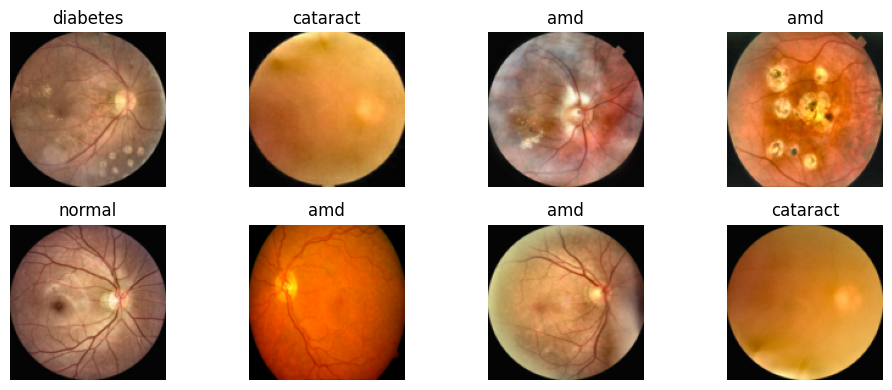

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))   # tensor is [C,H,W], matplotlib wants [H,W,C]
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()


## Step 4: Build the CNN

Basic idea of a CNN:
- **Conv layer** = a bunch of small 3x3 filters sliding over the image, each one learns to detect some pattern (edge, blob, texture etc.)
- **MaxPool** = shrinks the image size in half, keeps the strongest values
- After 3 conv+pool blocks, I flatten everything and pass through normal Linear layers to get the final class scores

I added a `p_dropout` argument so I can reuse this same class for both Round 1 (dropout off) and Round 2 (dropout on).


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4, p_dropout=0.0):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)   # 3 channels in (RGB) -> 16 filters
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 16 -> 32 filters
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32 -> 64 filters
        self.pool = nn.MaxPool2d(2, 2)                            # cuts H and W in half each time

        self.dropout = nn.Dropout(p_dropout)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)   # 128 -> 64 -> 32 -> 16 after 3 pools, 64 channels
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 128x128 -> 64x64
        x = self.pool(F.relu(self.conv2(x)))   # 64x64 -> 32x32
        x = self.pool(F.relu(self.conv3(x)))   # 32x32 -> 16x16
        x = x.view(x.size(0), -1)              # flatten to 1D per image
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleCNN(num_classes=num_classes, p_dropout=0.0).to(device)
print(model)

# count how many parameters this model has, need this number for the submission form
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('total trainable parameters:', total_params)


SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)
total trainable parameters: 2121380


## Step 5: Training function

This function does one full training run:
1. show the model a batch of training images
2. compare its guess to the real label using CrossEntropyLoss
3. backpropagation calculates how to adjust the weights
4. Adam optimizer applies the adjustment
5. after going through all training images (1 epoch), check accuracy on validation set

I wrote it as a function so I can call it twice (once per round) without copy-pasting the loop.


In [ ]:
def train_model(model, train_loader, valid_loader, epochs=25, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'valid_loss': [], 'train_acc': [], 'valid_acc': []}

    for epoch in range(epochs):
        # ---- training part ----
        model.train()
        running_loss = 0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- validation part (no weight updates here) ----
        model.eval()
        running_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        valid_loss = running_loss / total
        valid_acc = correct / total

        history['train_loss'].append(train_loss)
        history['valid_loss'].append(valid_loss)
        history['train_acc'].append(train_acc)
        history['valid_acc'].append(valid_acc)

        print(f'epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
              f'valid_loss={valid_loss:.4f}  valid_acc={valid_acc:.4f}')

    return history


## Step 6: Train Round 1 (no augmentation, no dropout)

In [ ]:
EPOCHS = 40
history_round1 = train_model(model, train_loader, valid_loader, epochs=EPOCHS, lr=0.001)


epoch 1/40  train_loss=1.3507  train_acc=0.3093  valid_loss=1.2328  valid_acc=0.3900
epoch 2/40  train_loss=1.0699  train_acc=0.5339  valid_loss=0.9872  valid_acc=0.5850
epoch 3/40  train_loss=0.9275  train_acc=0.5991  valid_loss=0.8956  valid_acc=0.6000
epoch 4/40  train_loss=0.7973  train_acc=0.6581  valid_loss=0.8718  valid_acc=0.6175
epoch 5/40  train_loss=0.7720  train_acc=0.6819  valid_loss=0.8359  valid_acc=0.6225
epoch 6/40  train_loss=0.6442  train_acc=0.7371  valid_loss=0.7452  valid_acc=0.6575
epoch 7/40  train_loss=0.6010  train_acc=0.7472  valid_loss=0.6606  valid_acc=0.6925
epoch 8/40  train_loss=0.5502  train_acc=0.7604  valid_loss=0.5794  valid_acc=0.7225
epoch 9/40  train_loss=0.4993  train_acc=0.7961  valid_loss=0.6265  valid_acc=0.7175
epoch 10/40  train_loss=0.4570  train_acc=0.8099  valid_loss=0.6764  valid_acc=0.6850
epoch 11/40  train_loss=0.4558  train_acc=0.8156  valid_loss=0.5746  valid_acc=0.7450
epoch 12/40  train_loss=0.4097  train_acc=0.8225  valid_loss=0.

### Plot Round 1 curves

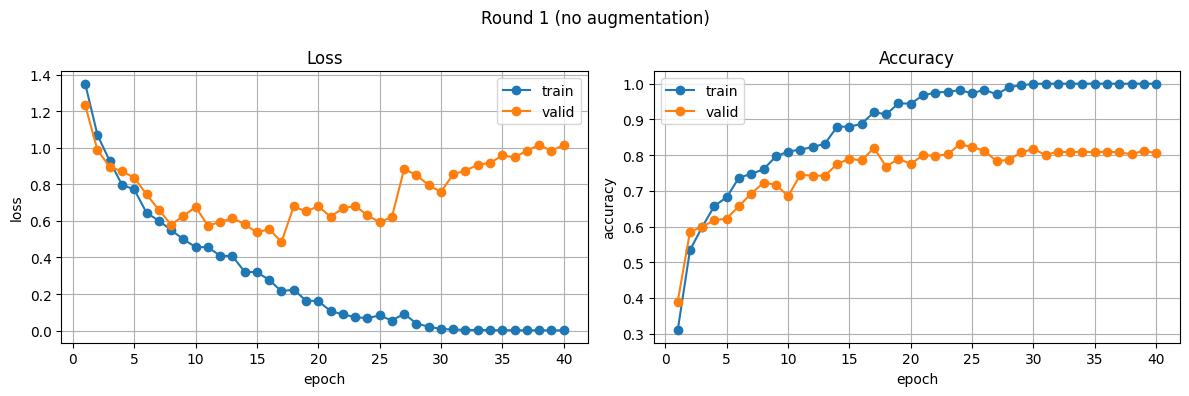

In [ ]:
def plot_curves(history, title):
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs_range, history['train_loss'], 'o-', label='train')
    ax1.plot(epochs_range, history['valid_loss'], 'o-', label='valid')
    ax1.set_title('Loss')
    ax1.set_xlabel('epoch')
    ax1.set_ylabel('loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs_range, history['train_acc'], 'o-', label='train')
    ax2.plot(epochs_range, history['valid_acc'], 'o-', label='valid')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('epoch')
    ax2.set_ylabel('accuracy')
    ax2.legend()
    ax2.grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    safe_name = title.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'{safe_name}.png', dpi=150)
    plt.show()

plot_curves(history_round1, 'Round 1 (no augmentation)')


## Step 7: What does the overfitting look like?

If train accuracy keeps going up but valid accuracy flattens out or starts going down (and valid loss starts going back up), that means the model is **memorizing** the training images instead of actually learning the general pattern of each disease. That's overfitting.

Small dataset (2000 images) + a model that has a lot of parameters = easy to memorize, so I expect to see this happen in Round 1.


## Step 8: Look inside the CNN - visualize what conv1 learned

Just to understand what's actually happening inside the model:
1. the actual filter weights of the first conv layer (each filter is a tiny 3x3x3 colored square)
2. feature maps - what conv1's output looks like when I feed it one real image


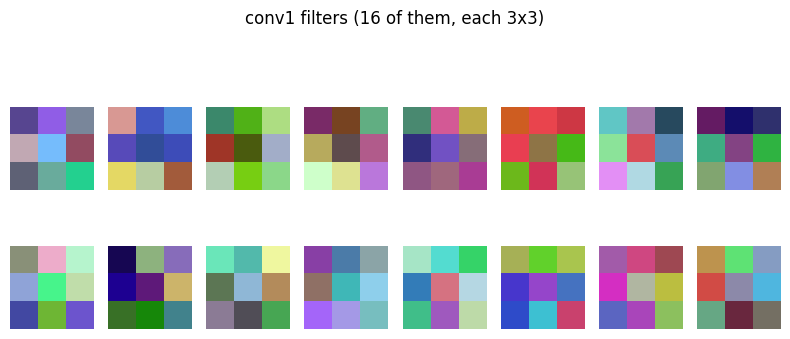

In [ ]:
# filters of conv1
filters = model.conv1.weight.data.clone().cpu()   # shape [16, 3, 3, 3]

# scale to 0-1 so it can be shown as an image
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min + 1e-8)

plt.figure(figsize=(8, 4))
for i in range(16):
    plt.subplot(2, 8, i + 1)
    plt.imshow(filters[i].permute(1, 2, 0))
    plt.axis('off')
plt.suptitle('conv1 filters (16 of them, each 3x3)')
plt.tight_layout()
plt.show()


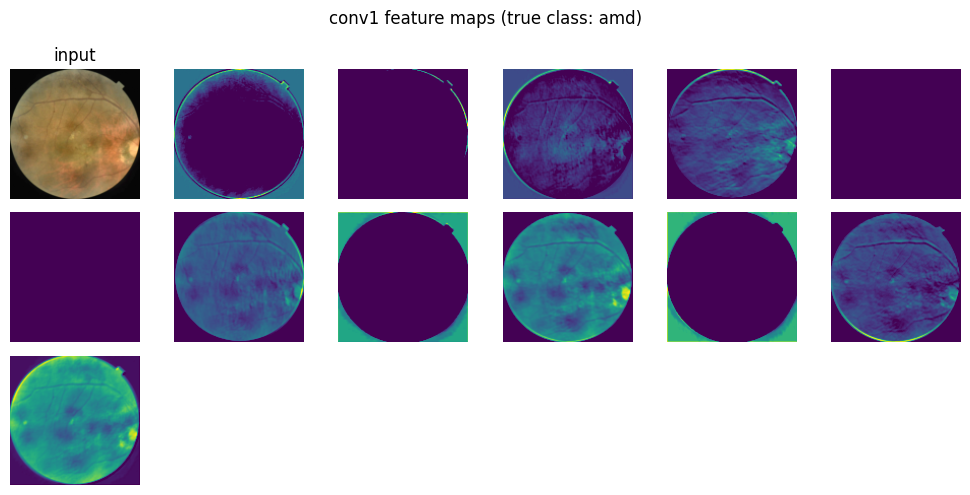

In [ ]:
# feature maps - response of conv1 to one real validation image
img, label = valid_data[0]
img_batch = img.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    feature_maps = F.relu(model.conv1(img_batch)).cpu()[0]

plt.figure(figsize=(10, 5))
plt.subplot(3, 6, 1)
plt.imshow(img.permute(1, 2, 0))
plt.title('input')
plt.axis('off')
for i in range(12):
    plt.subplot(3, 6, i + 2)
    plt.imshow(feature_maps[i], cmap='viridis')
    plt.axis('off')
plt.suptitle(f'conv1 feature maps (true class: {class_names[label]})')
plt.tight_layout()
plt.show()


## Step 9: Fix overfitting - Round 2 (augmentation + dropout)

Two things I'm adding now:

1. **Data augmentation** - randomly flip/rotate/change brightness of training images so the model sees a slightly different version every epoch, instead of literally memorizing the same 1600 images over and over. Only applied to the training set, not validation (validation should stay "clean" so the accuracy number means something).
2. **Dropout** - randomly turns off half the neurons in the fully connected layers during training, so the model can't rely too much on any single neuron.

Everything else (architecture, epochs, learning rate) stays the same so it's a fair before/after comparison.


In [ ]:
# training transform WITH augmentation this time
# (kept it lighter than my first try - ColorJitter + dropout 0.5 together was too
# aggressive and the model couldn't learn properly, so just flip + small rotation now)
train_transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

# valid transform stays the same as before, no augmentation
valid_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_data_aug = datasets.ImageFolder(train_dir, transform=train_transform_aug)
valid_data_clean = datasets.ImageFolder(valid_dir, transform=valid_transform)

train_loader_aug = DataLoader(train_data_aug, batch_size=BATCH_SIZE, shuffle=True)
valid_loader_clean = DataLoader(valid_data_clean, batch_size=BATCH_SIZE, shuffle=False)


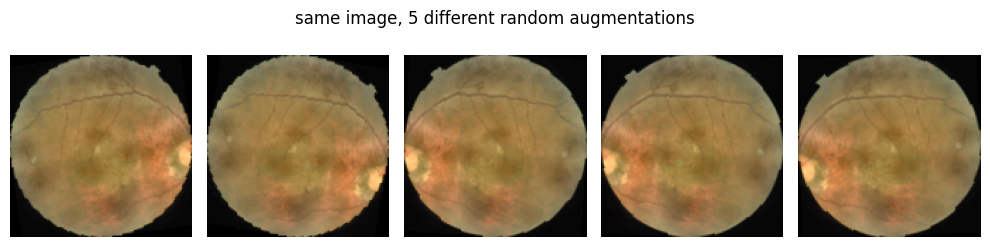

In [ ]:
# check what augmentation actually does to the same image
sample_img, _ = train_data_aug[0]
plt.figure(figsize=(10, 2.5))
for i in range(5):
    aug_img, _ = train_data_aug[0]   # re-fetching applies a new random augmentation each time
    plt.subplot(1, 5, i + 1)
    plt.imshow(aug_img.permute(1, 2, 0))
    plt.axis('off')
plt.suptitle('same image, 5 different random augmentations')
plt.tight_layout()
plt.show()


epoch 1/40  train_loss=1.2821  train_acc=0.3971  valid_loss=1.1510  valid_acc=0.4850
epoch 2/40  train_loss=1.0990  train_acc=0.5402  valid_loss=1.1746  valid_acc=0.4750
epoch 3/40  train_loss=1.0047  train_acc=0.5671  valid_loss=0.9388  valid_acc=0.5650
epoch 4/40  train_loss=0.9280  train_acc=0.6066  valid_loss=0.9080  valid_acc=0.6050
epoch 5/40  train_loss=0.8283  train_acc=0.6619  valid_loss=0.9412  valid_acc=0.5975
epoch 6/40  train_loss=0.7652  train_acc=0.6838  valid_loss=0.7971  valid_acc=0.6125
epoch 7/40  train_loss=0.7015  train_acc=0.7158  valid_loss=0.7063  valid_acc=0.6575
epoch 8/40  train_loss=0.6705  train_acc=0.7127  valid_loss=0.7507  valid_acc=0.6800
epoch 9/40  train_loss=0.6259  train_acc=0.7346  valid_loss=0.6413  valid_acc=0.6800
epoch 10/40  train_loss=0.6596  train_acc=0.7158  valid_loss=0.6768  valid_acc=0.7125
epoch 11/40  train_loss=0.6249  train_acc=0.7440  valid_loss=0.6385  valid_acc=0.7125
epoch 12/40  train_loss=0.5799  train_acc=0.7591  valid_loss=0.

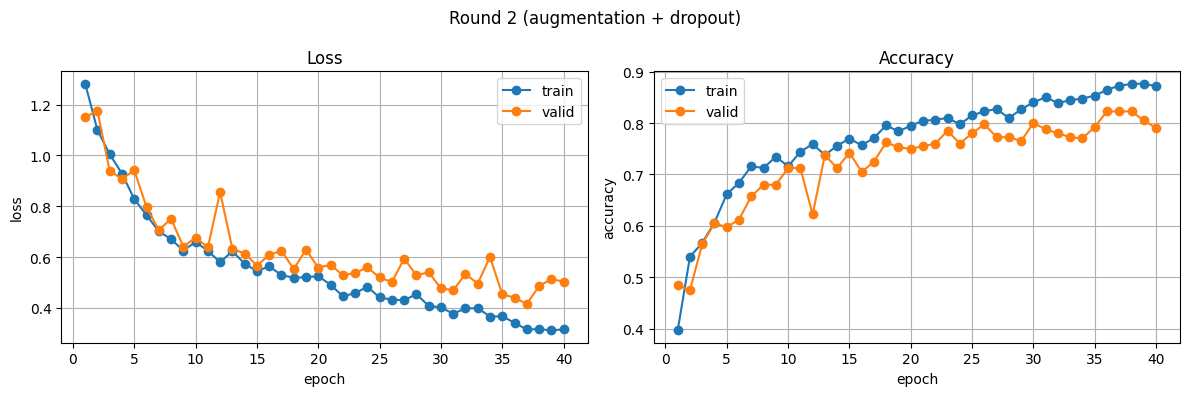

In [ ]:
# new model, this time with dropout turned on
# using 0.3 instead of 0.5 - first attempt with 0.5 + augmentation together
# was too strong and made the model underfit (train accuracy couldn't even get high)
model_round2 = SimpleCNN(num_classes=num_classes, p_dropout=0.3).to(device)

history_round2 = train_model(model_round2, train_loader_aug, valid_loader_clean, epochs=EPOCHS, lr=0.001)
plot_curves(history_round2, 'Round 2 (augmentation + dropout)')


## Step 10: Compare Round 1 vs Round 2

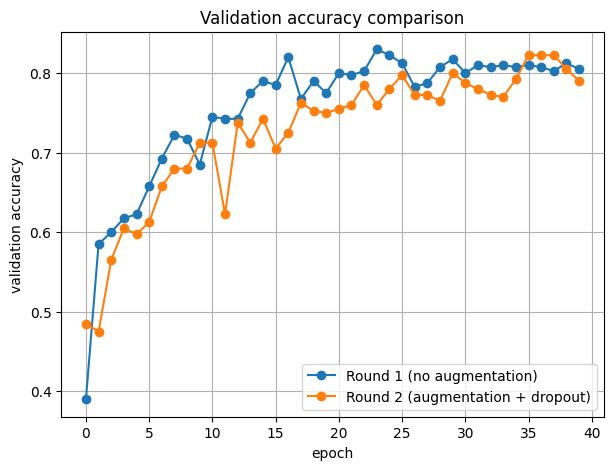

best valid accuracy round 1: 0.83
best valid accuracy round 2: 0.8225
best valid loss round 1: 0.48452140286564827
best valid loss round 2: 0.41617903955280783
train-valid accuracy gap round 1: 0.17000000000000004
train-valid accuracy gap round 2: 0.0539115432873275


In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(history_round1['valid_acc'], 'o-', label='Round 1 (no augmentation)')
plt.plot(history_round2['valid_acc'], 'o-', label='Round 2 (augmentation + dropout)')
plt.title('Validation accuracy comparison')
plt.xlabel('epoch')
plt.ylabel('validation accuracy')
plt.legend()
plt.grid(True)
plt.savefig('round1_vs_round2.png', dpi=150)
plt.show()

gap_round1 = max(history_round1['train_acc']) - max(history_round1['valid_acc'])
gap_round2 = max(history_round2['train_acc']) - max(history_round2['valid_acc'])

print('best valid accuracy round 1:', max(history_round1['valid_acc']))
print('best valid accuracy round 2:', max(history_round2['valid_acc']))
print('best valid loss round 1:', min(history_round1['valid_loss']))
print('best valid loss round 2:', min(history_round2['valid_loss']))
print('train-valid accuracy gap round 1:', gap_round1)
print('train-valid accuracy gap round 2:', gap_round2)


If round 2's gap is smaller than round 1's gap, that's my evidence that dropout + augmentation actually reduced overfitting.

## Step 11: Confusion matrix for the final model (Round 2)

              precision    recall  f1-score   support

         amd       0.72      0.92      0.81       100
    cataract       1.00      0.93      0.96       100
    diabetes       0.72      0.53      0.61       100
      normal       0.74      0.78      0.76       100

    accuracy                           0.79       400
   macro avg       0.79      0.79      0.79       400
weighted avg       0.79      0.79      0.79       400



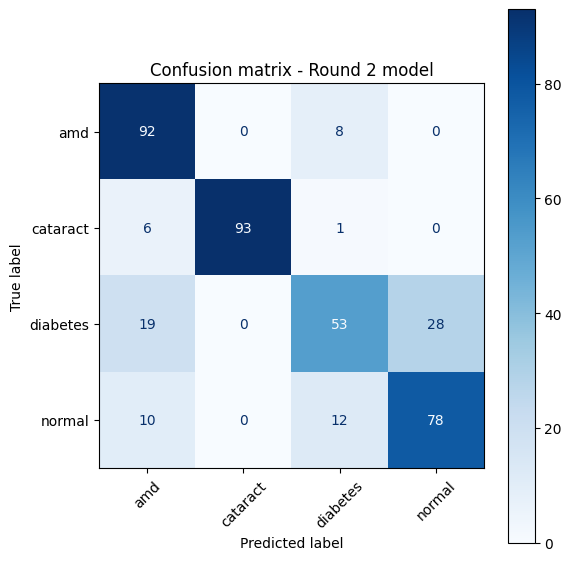

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def get_all_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return all_preds, all_labels

preds, actual = get_all_predictions(model_round2, valid_loader_clean)

print(classification_report(actual, preds, target_names=class_names))

cm = confusion_matrix(actual, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion matrix - Round 2 model')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
